# **Imports**

In [7]:
%pip install pandas

import numpy as np
import pandas as pd


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\marti\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# **Preprocesamiento**

## Detección de Outliers

In [2]:
C = [3, 1, 0, 2, 7, 3, 6, 4, -2, 0, 0, 10, 15, 6]

###Encontrando outliers por medio de desviaciones estándar
def outliers_std(std):
    print(f"Calculando outliers con +- {std} desviaciones estándar...")
    outliers = []
    mean = np.mean(C)
    std_dev = np.std(C)
    print(f"Media: {mean}, Desviación estándar: {std_dev}")
    for value in C:
        if abs(value - mean) > std * std_dev:
            print(f"    Valor {value} es un outlier ({abs(value - mean)} > {std* std_dev})")
            outliers.append(value)
        else:
            print(f"    Valor {value} no es un outlier ({abs(value - mean)} <= {std* std_dev})")
    return outliers

In [3]:
#+- 3 desviaciones estándar
outliers = outliers_std(3)
print("Outliers (3 std):", outliers)

#+-2 Desviaciones estándar
outliers_2std = outliers_std(2)
print("Outliers (2 std):", outliers_2std)

#+-1 Desviación estándar
outliers_1std = outliers_std(1)
print("Outliers (1 std):", outliers_1std)

Calculando outliers con +- 3 desviaciones estándar...
Media: 3.9285714285714284, Desviación estándar: 4.4153027030073115
    Valor 3 no es un outlier (0.9285714285714284 <= 13.245908109021935)
    Valor 1 no es un outlier (2.9285714285714284 <= 13.245908109021935)
    Valor 0 no es un outlier (3.9285714285714284 <= 13.245908109021935)
    Valor 2 no es un outlier (1.9285714285714284 <= 13.245908109021935)
    Valor 7 no es un outlier (3.0714285714285716 <= 13.245908109021935)
    Valor 3 no es un outlier (0.9285714285714284 <= 13.245908109021935)
    Valor 6 no es un outlier (2.0714285714285716 <= 13.245908109021935)
    Valor 4 no es un outlier (0.07142857142857162 <= 13.245908109021935)
    Valor -2 no es un outlier (5.928571428571429 <= 13.245908109021935)
    Valor 0 no es un outlier (3.9285714285714284 <= 13.245908109021935)
    Valor 0 no es un outlier (3.9285714285714284 <= 13.245908109021935)
    Valor 10 no es un outlier (6.071428571428571 <= 13.245908109021935)
    Valor 15 n

## Normalización

In [4]:
def min_max_normalization(array):
    print("Calculando normalización Min-Max...")
    array_min = np.min(array)
    array_max = np.max(array)
    print(f"Min: {array_min}, Max: {array_max}")
    normalized_array = (array - array_min) / (array_max - array_min)
    return np.array(normalized_array)

def z_score_normalization(array):
    print("Calculando normalización Z-Score...")
    mean = np.mean(array)
    std_dev = np.std(array)
    print(f"Media: {mean}, Desviación estándar: {std_dev}")
    z_normalized_array = (array - mean) / std_dev if std_dev != 0 else array - mean
    return np.array(z_normalized_array)

In [5]:
# Normalización Min-Max
array = [20, 23, 25, 26, 29, 34, 35, 37, 39, 40]
print("Array original:", array, "\n")
normalized_array = min_max_normalization(array)
print("Array normalizado (Min-Max):", normalized_array, "\n")
# Normalización Z-Score
z_normalized_array = z_score_normalization(array)
print("Array normalizado (Z-Score):", z_normalized_array)

Array original: [20, 23, 25, 26, 29, 34, 35, 37, 39, 40] 

Calculando normalización Min-Max...
Min: 20, Max: 40
Array normalizado (Min-Max): [0.   0.15 0.25 0.3  0.45 0.7  0.75 0.85 0.95 1.  ] 

Calculando normalización Z-Score...
Media: 30.8, Desviación estándar: 6.749814812274482
Array normalizado (Z-Score): [-1.6000439  -1.15558726 -0.85928283 -0.71113062 -0.26667398  0.47408708
  0.62223929  0.91854372  1.21484814  1.36300036]


## Discretización

### *Técnica BIN*

In [6]:
I1 = [1, 2, 1, 2, 1, 1, 2]
I2 = [5.9, 2.1, 1.6, 6.8, 3.1, 8.3, 2.4] # Uso de la Media como representante
I3 = [3.4, 6.2, 2.8, 5.8, 3.1, 4.1, 5.0] # Uso del Límite más cercano como Representante

In [7]:
def BIN_error(original, binned):
    error = 0
    for o, b in zip(original, binned):
        error += (o - b) ** 2
    return error

In [8]:
I1 = np.sort(I1)
I2 = np.sort(I2)
print("I1:", I1)
print("I2:", I2)

I1: [1 1 1 1 2 2 2]
I2: [1.6 2.1 2.4 3.1 5.9 6.8 8.3]


In [ ]:
def find_best_BIN(original, representative='mean'):
    original = np.sort(original)
    best_error = float('inf')
    best_binned = None
    bin_index = 1
    for i in range(1, len(original) + 1):
        g1 = original[:i]
        g2 = original[i:]
        if representative == 'mean':
            binned = [np.mean(g1)] * len(g1) + [np.mean(g2)] * len(g2)
        elif representative == 'nearest':
            binned = [g1[0]] * len(g1) + [g2[-1]] * len(g2)
        error = BIN_error(original, binned)

        binned_clean = [float(x) for x in binned]

        if error < best_error:
            best_error = error
            best_binned = binned
            bin_index = i
    print(f"Mejor BIN encontrado en el índice {bin_index} y error {best_error}")
    print(f"Original: {[float(x) for x in original]}")
    print(f"Mejor BIN: {[float(x) for x in best_binned]}")
    print("Grupos:")
    print(f"Grupo 1: {[float(x) for x in original[:bin_index]]}")
    print(f"Grupo 2: {[float(x) for x in original[bin_index:]]}")
    return best_binned, best_error, bin_index

In [11]:
print("\nEvaluando I2:")
find_best_BIN(I2)



Evaluando I2:
Mejor BIN encontrado en el índice 4 y error 4.120000000000001
Original: [1.6, 2.1, 2.4, 3.1, 5.9, 6.8, 8.3]
Mejor BIN: [2.3, 2.3, 2.3, 2.3, 7.0, 7.0, 7.0]
Grupos:
Grupo 1: [1.6, 2.1, 2.4, 3.1]
Grupo 2: [5.9, 6.8, 8.3]


([np.float64(2.3),
  np.float64(2.3),
  np.float64(2.3),
  np.float64(2.3),
  np.float64(7.0),
  np.float64(7.0),
  np.float64(7.0)],
 np.float64(4.120000000000001),
 4)

In [8]:
def initial_state():
    R1 = ['A', 'X', 1]
    R2 = ['B', 'Y', 2]
    R3 = ['C', 'Y', 2]
    R4 = ['B', 'X', 1]
    R5 = ['C', 'Z', 3]
    records = [R1, R2, R3, R4, R5]
    return records

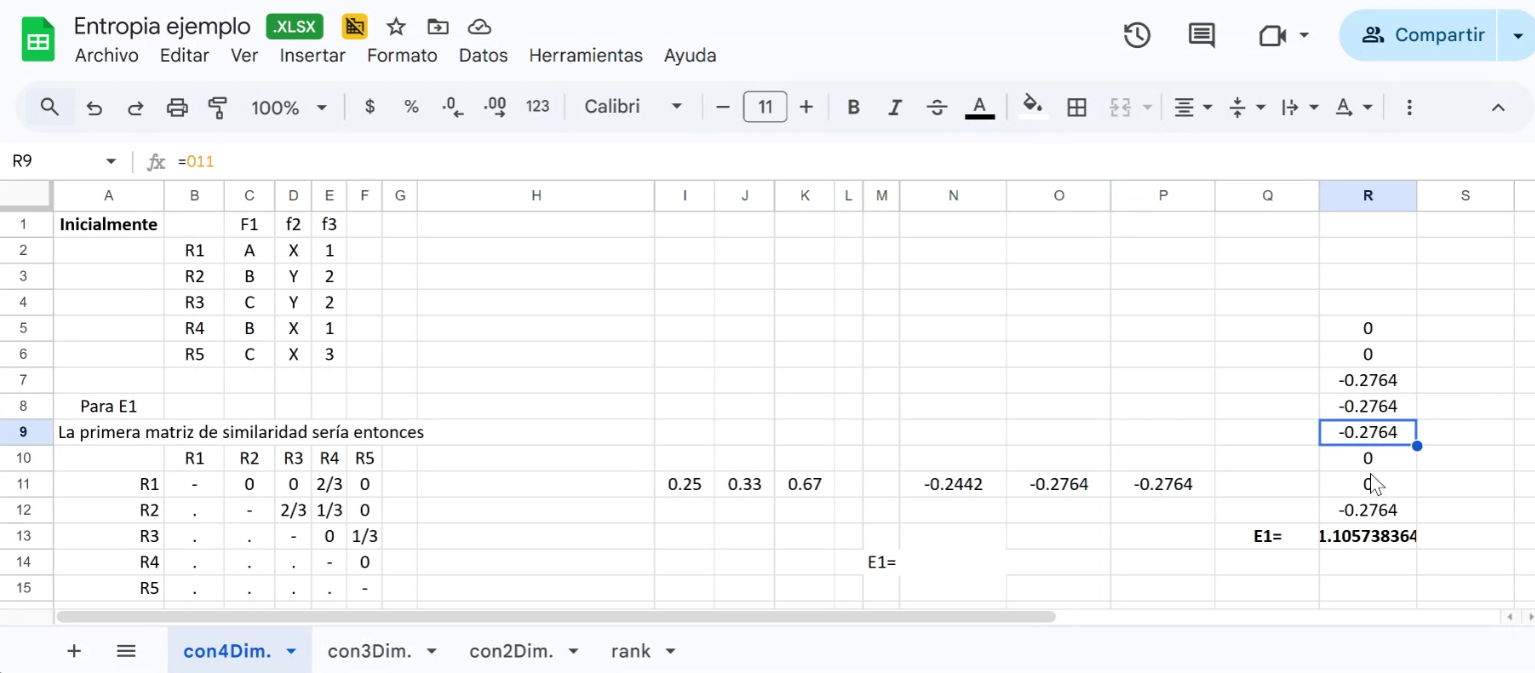

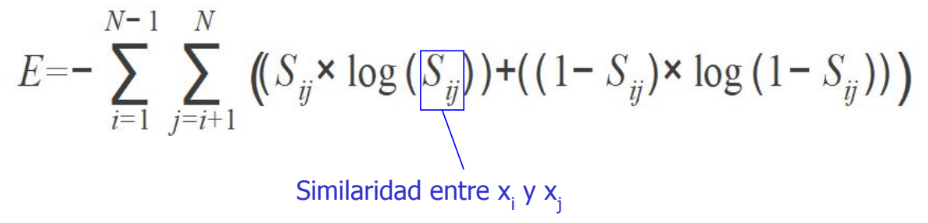

In [17]:
def entropy(matrix_similarity):
    entropy = 0
    for row in matrix_similarity:
        for value in row:
            if value > 0:
                entropy -= (value * np.log10(value))+((1-value)*np.log10(1-value))
    return entropy

In [4]:
def delete_attribute(index):
    records = initial_state()
    print("Registros iniciales:")
    print(records)
    print(f"Eliminando atributo en índice {index}...")
    modified_records = records.copy()
    if index < 0 or index >= len(records[0]):
        print("Índice fuera de rango. No se eliminará ningún atributo.")
        return records
    for record in modified_records:
        del record[index]
    print("Registros después de eliminar el atributo:")
    print(modified_records)
    return modified_records

In [11]:
def similarity_matrix(records):
    num_records = len(records)
    matrix = np.zeros((num_records, num_records))
    for i in range(num_records):
        for j in range(num_records):
            if i < j:  # Solo calcula para la parte superior de la diagonal
                matches = sum(1 for a, b in zip(records[i], records[j]) if a == b)
                matrix[i][j] = matches/len(records[i])
    return matrix

In [15]:
print(similarity_matrix(initial_state()))

[[0.         0.         0.         0.66666667 0.        ]
 [0.         0.         0.66666667 0.33333333 0.        ]
 [0.         0.         0.         0.         0.33333333]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]]


In [18]:
print(entropy(similarity_matrix(initial_state())))

1.1057383637746998


Calcular el Atributo a Eliminar

In [ ]:
def calculate_attribute_to_delete(records):
    num_attributes = len(records[0])
    original_entropy = entropy(similarity_matrix(records))  
    entropy_list = []
    
    for index in range(num_attributes):
        modified_records = delete_attribute(index)
        matrix = similarity_matrix(modified_records)
        current_entropy = entropy(matrix)
        print(f"Entropía después de eliminar el atributo {index}: {current_entropy}")
        entropy_substracted = original_entropy - current_entropy
        print(f"Reducción de entropía al eliminar el atributo {index}: {entropy_substracted}")
        entropy_list.append((index, entropy_substracted))
    
    # Ordenar por entropía (ascendente - menor entropía es mejor)
    entropy_list.sort(key=lambda x: x[1])
    
    # Extraer solo los índices ordenados
    ordered_indices = [idx for idx, _ in entropy_list]
    
    print(f"\nÍndices ordenados por entropía (mejor a peor):")
    for idx, ent in entropy_list:
        print(f"  Atributo {idx}: entropía = {ent}")
    
    print(f"\nLista de índices en orden a eliminar: {ordered_indices}")
    return ordered_indices

In [24]:
calculate_attribute_to_delete(initial_state())

Registros iniciales:
[['A', 'X', 1], ['B', 'Y', 2], ['C', 'Y', 2], ['B', 'X', 1], ['C', 'Z', 3]]
Eliminando atributo en índice 0...
Registros después de eliminar el atributo:
[['X', 1], ['Y', 2], ['Y', 2], ['X', 1], ['Z', 3]]
Entropía después de eliminar el atributo 0: nan
Reducción de entropía al eliminar el atributo 0: nan
Registros iniciales:
[['A', 'X', 1], ['B', 'Y', 2], ['C', 'Y', 2], ['B', 'X', 1], ['C', 'Z', 3]]
Eliminando atributo en índice 1...
Registros después de eliminar el atributo:
[['A', 1], ['B', 2], ['C', 2], ['B', 1], ['C', 3]]
Entropía después de eliminar el atributo 1: 1.2041199826559248
Reducción de entropía al eliminar el atributo 1: -0.09838161888122499
Registros iniciales:
[['A', 'X', 1], ['B', 'Y', 2], ['C', 'Y', 2], ['B', 'X', 1], ['C', 'Z', 3]]
Eliminando atributo en índice 2...
Registros después de eliminar el atributo:
[['A', 'X'], ['B', 'Y'], ['C', 'Y'], ['B', 'X'], ['C', 'Z']]
Entropía después de eliminar el atributo 2: 1.2041199826559248
Reducción de en

C:\Users\marti\AppData\Local\Temp\ipykernel_4384\1806740207.py:6: RuntimeWarning: divide by zero encountered in log10
  entropy -= (value * np.log10(value))+((1-value)*np.log10(1-value))
C:\Users\marti\AppData\Local\Temp\ipykernel_4384\1806740207.py:6: RuntimeWarning: invalid value encountered in scalar multiply
  entropy -= (value * np.log10(value))+((1-value)*np.log10(1-value))


[0, 1, 2]

### Eliminamos f1

In [33]:
records_f1 = delete_attribute(0)

Registros iniciales:
[['A', 'X', 1], ['B', 'Y', 2], ['C', 'Y', 2], ['B', 'X', 1], ['C', 'Z', 3]]
Eliminando atributo en índice 0...
Registros después de eliminar el atributo:
[['X', 1], ['Y', 2], ['Y', 2], ['X', 1], ['Z', 3]]


In [ ]:
print("Calculando similitudes entre registros...")
print(similarity_matrix(records_f1))

Calculando similitudes entre registros...
[[0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


Matriz de Similitud

In [ ]:
#matrix_similarity = np.zeros((5, 5))


### Eliminamos f2

In [34]:
records_f2 = delete_attribute(1)

Registros iniciales:
[['A', 'X', 1], ['B', 'Y', 2], ['C', 'Y', 2], ['B', 'X', 1], ['C', 'Z', 3]]
Eliminando atributo en índice 1...
Registros después de eliminar el atributo:
[['A', 1], ['B', 2], ['C', 2], ['B', 1], ['C', 3]]


### Eliminamos f3

In [36]:
records_f3 = delete_attribute(2)

Registros iniciales:
[['A', 'X', 1], ['B', 'Y', 2], ['C', 'Y', 2], ['B', 'X', 1], ['C', 'Z', 3]]
Eliminando atributo en índice 2...
Registros después de eliminar el atributo:
[['A', 'X'], ['B', 'Y'], ['C', 'Y'], ['B', 'X'], ['C', 'Z']]


Ordenar cual tiene mayor o menor entropía y decir por qué sucede esto

## **Selección de Características - Entropía**

---

**Curso:** Minería de Datos - 2019773  
**Docente:** Elizabeth León Guzmán  
**Institución:** Universidad Nacional de Colombia  
**Estudiante:** Nicolás Martínez López

---

### **Librerías**

In [ ]:
%pip install pandas

import numpy as np
import pandas as pd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\marti\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### **Desarrollo del Ejercicio**

In [ ]:
def initial_state():
    R1 = ['A', 'X', 1]
    R2 = ['B', 'Y', 2]
    R3 = ['C', 'Y', 2]
    R4 = ['B', 'X', 1]
    R5 = ['C', 'Z', 3]
    records = [R1, R2, R3, R4, R5]
    return records

Cálculo de la Entropía recibiendo como parámetro la matriz de similaridad.

In [ ]:
def entropy(matrix_similarity):
    #print('Matriz de similitud usada en la entropía:', matrix_similarity)
    entropy = 0
    for row in matrix_similarity:
        for value in row:
            if value > 0:
                entropy -= (value * np.log10(value))+((1-value)*np.log10(1-value))
    
    # Verificar si entropy es NaN y retornar infinito en ese caso
    if np.isnan(entropy):
        #print(f"Entropía calculada: inf (se detectó NaN)")
        return -np.inf
    
    #print(f"Entropía calculada: {entropy}")
    return entropy

Este método recibe un conjunto de datos / dataset y elimina una columna de el a partír de un índice.

In [ ]:
def delete_attribute(index, records, attributes):
    #print("Registros iniciales:")
    #print("     →",records)
    print(f"    → Eliminando atributo {attributes[index]}...")
    modified_records = records.copy()
    if index < 0 or index >= len(records[0]):
        print("    Índice fuera de rango. No se eliminará ningún atributo.")
        return records
    for record in modified_records:
        del record[index]
    #print("Registros después de eliminar el atributo:")
    #print(modified_records, end="\n")
    return modified_records

Método que calcula la matriz de similaridad a partír del conjunto de datos, recordemos que esta matríz tiene únicamente valores en los elementos que se encuentran en la parte superior de la diagonal príncipal

In [ ]:
def similarity_matrix(records):
    num_records = len(records)
    matrix = np.zeros((num_records, num_records))
    for i in range(num_records):
        for j in range(num_records):
            if i < j:  # Solo calcula para la parte superior de la diagonal
                matches = sum(1 for a, b in zip(records[i], records[j]) if a == b)
                matrix[i][j] = matches/len(records[i])
    return matrix

In [ ]:
print(similarity_matrix(initial_state()))

[[0.         0.         0.         0.66666667 0.        ]
 [0.         0.         0.66666667 0.33333333 0.        ]
 [0.         0.         0.         0.         0.33333333]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]]


Esto fue lo que se hizo en clase en donde se halló la entropía del conjunto de datos original

In [ ]:
print(entropy(similarity_matrix(initial_state())))

1.1057383637746998


El siguiente método tiene como función encontrar el atributo elegible a eliminar a partir del conjunto de datos

In [ ]:
def calculate_attribute_to_delete(records, attributes):
    num_attributes = len(records[0])
    original_entropy = entropy(similarity_matrix(records))  
    print(f'Entropía Original: {original_entropy}')
    entropy_list = []
       
    for index in range(num_attributes):
        # Crear una copia profunda para cada iteración
        dataset = [row[:] for row in records]
        modified_records = delete_attribute(index, dataset, attributes)
        matrix = similarity_matrix(modified_records)
        current_entropy = entropy(matrix)
        entropy_substracted = np.abs(original_entropy - current_entropy)
        print(f"    → Entropía al Quitar la Columna {index}: {current_entropy}, Reducción de entropía: {entropy_substracted}", end="\n\n")
        entropy_list.append((index, entropy_substracted))
    
    # Ordenar por entropía (ascendente - menor entropía es mejor)
    entropy_list.sort(key=lambda x: x[1])
    
    # Extraer solo los índices ordenados
    ordered_indices = [idx for idx, _ in entropy_list]
    
    #print(f"\nÍndices ordenados por entropía (mejor a peor):")
    # for idx, ent in entropy_list:
    #     print(f"  Atributo {idx}: entropía = {ent}")
    
    #print(f"\nLista de índices en orden a eliminar: {ordered_indices}")
    print(f"    → Ranking Variables: { [attributes[i] for i in ordered_indices] }")
    #print(f'    → Índice Seleccionado para eliminar: {ordered_indices[0]}')
    return ordered_indices[0]

In [ ]:
original_dataset = initial_state()

Reducción de Dimensionalidad (a 1 Dimensión)

In [ ]:
def dimensionality_reduction(records, attributes):
    num_atributes = len(records[0])
    records_iteration = [row[:] for row in records]  # Crear una copia profunda de los registros
    ranking = []
    print(f"Dataset inicial: {records_iteration}")
    print(f"Variables iniciales: {attributes}")
    for i in range(num_atributes-1):
        print(f"\nIteración {i+1}:")
        att = calculate_attribute_to_delete(records_iteration, attributes)
        records_iteration = delete_attribute(att, records_iteration, attributes)
        ranking.append(attributes[att])
        attributes.pop(att)  
        print(f'    Resultado Iteración {i+1}: {records_iteration}')
    print(f"\nVariables eliminadas en orden: {ranking}")
    return records_iteration, ranking

In [ ]:
final_dataset, ranking = dimensionality_reduction(original_dataset, ['F1', 'F2', 'F3'])

Dataset inicial: [['A', 'X', 1], ['B', 'Y', 2], ['C', 'Y', 2], ['B', 'X', 1], ['C', 'Z', 3]]
Variables iniciales: ['F1', 'F2', 'F3']

Iteración 1:
Entropía Original: 1.1057383637746998
    → Eliminando atributo F1...
    → Entropía al Quitar la Columna 0: -inf, Reducción de entropía: inf

    → Eliminando atributo F2...
    → Entropía al Quitar la Columna 1: 1.2041199826559248, Reducción de entropía: 0.09838161888122499

    → Eliminando atributo F3...
    → Entropía al Quitar la Columna 2: 1.2041199826559248, Reducción de entropía: 0.09838161888122499

    → Ranking Variables: ['F2', 'F3', 'F1']
    → Eliminando atributo F2...
    Resultado Iteración 1: [['A', 1], ['B', 2], ['C', 2], ['B', 1], ['C', 3]]

Iteración 2:
Entropía Original: 1.2041199826559248
    → Eliminando atributo F1...
    → Entropía al Quitar la Columna 0: -inf, Reducción de entropía: inf

    → Eliminando atributo F3...
    → Entropía al Quitar la Columna 1: -inf, Reducción de entropía: inf

    → Ranking Variables:

C:\Users\marti\AppData\Local\Temp\ipykernel_30376\3090506168.py:7: RuntimeWarning: divide by zero encountered in log10
  entropy -= (value * np.log10(value))+((1-value)*np.log10(1-value))
C:\Users\marti\AppData\Local\Temp\ipykernel_30376\3090506168.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  entropy -= (value * np.log10(value))+((1-value)*np.log10(1-value))


### **Explicación de Cada Iteración**

### Funcionamiento

En cada iteración se realizan los siguientes pasos:
*   Calcular la matriz de similitud del dataset de la iteración actual
*   Calcular la entropía de la matriz de similitud de este dataset
*   Para cada una de las variables existentes:
    *   Eliminar la variable del dataset
    *   Calcular la matriz de Similitud del nuevo dataset
    *   Calcular la entropía de esta matriz de similitud
    *   Restar la entropía del dataset original con la entropía del dataset con la variable eliminada
*   Ordenar de menor a mayor las entropías obtenidas al eliminar la variable i del dataset
*   Obtener el dataset reducido al eliminar la variable en la primera posición del ordenamiento

### Análisis y Explicación de Cada Iteración

En primer lugar, recordemos que la **entropía** es una medida de incertidumbre o desorden en un conjunto de datos. En el contexto de selección de características, se utiliza para evaluar qué tan homogéneos o heterogéneos son los registros entre sí.

**Interpretación:**

- **Entropía baja**: Los registros son más similares entre sí (menor incertidumbre).
- **Entropía alta**: Los registros son más diversos o diferentes (mayor incertidumbre).

**Objetivo en Selección de Características:**

El objetivo es **eliminar el atributo que menos afecte la entropía** (es decir, que cause la menor reducción de entropía), ya que esto significa que dicho atributo aporta menos información distintiva al conjunto de datos.

#### ***Iteración 1***

En esta iteración se tiene el siguiente dataset o conjunto de datos:

| Registro | F1 | F2 | F3 |
|----------|-----------|-----------|-----------|
| R1       | A         | X         | 1         |
| R2       | B         | Y         | 2         |
| R3       | C         | Y         | 2         |
| R4       | B         | X         | 1         |
| R5       | C         | Z         | 3         |


La entropía de este dataset es de $1.1057383637746998$

Al eliminar cada atributo se obtienen las siguientes entropías:

**Al eliminar F1:**

| Registro | F2 | F3 |
|----------|-----------|-----------|
| R1       | X         | 1         |
| R2       | Y         | 2         |
| R3       | Y         | 2         |
| R4       | X         | 1         |
| R5       | Z         | 3         |

- **Entropía:** $-\infty$
- **Reducción de entropía:** $\infty$
- **Interpretación:** F1 es el atributo que aporta **mayor diversidad** a los datos. Al eliminarlo, la matriz de similaridad tiene elementos con valor 1 (registros idénticos), lo que causa $\log_{10}(1-1) = \log_{10}(0)$, resultando en $-\infty$.

**Al eliminar F2:**

| Registro | F1 | F3 |
|----------|-----------|-----------|
| R1       | A         | 1         |
| R2       | B         | 2         |
| R3       | C         | 2         |
| R4       | B         | 1         |
| R5       | C         | 3         |

- **Entropía:** $1.2041199826559248$
- **Reducción de entropía:** $-0.09838161888122499$
- **Interpretación:** Al eliminar F2, la entropía **aumenta** (reducción negativa), lo que indica que F2 aporta cierta información distintiva.

**Al eliminar F3:**

| Registro | F1 | F2 |
|----------|-----------|-----------|
| R1       | A         | X         |
| R2       | B         | Y         |
| R3       | C         | Y         |
| R4       | B         | X         |
| R5       | C         | Z         |

- **Entropía:** $1.2041199826559248$
- **Reducción de entropía:** $-0.09838161888122499$
- **Interpretación:** Similar a F2, al eliminar F3 la entropía aumenta en la misma magnitud.


**¿Por qué F1 aporta mayor diversidad?**

F1 es el atributo más importante para mantener la distinción entre los registros. Esto se evidencia porque:

1. **Sin F1, hay registros idénticos:** Al eliminar F1 y conservar solo [F2, F3]:
   - R1 = [X, 1] y R4 = [X, 1] son idénticos (similaridad = 1.0)
   - R2 = [Y, 2] y R3 = [Y, 2] son idénticos (similaridad = 1.0)

2. **Sin F2 o F3, no hay registros idénticos:** Al eliminar F2 o F3, todos los registros mantienen alguna diferencia, no hay pares con similaridad perfecta (1.0).

3. **Impacto matemático:** Cuando dos registros son idénticos, su similaridad es 1.0, y al calcular la entropía se evalúa $\log_{10}(1-1) = \log_{10}(0) = -\infty$, lo que genera una entropía infinita negativa.

**F1 es el atributo que más **discrimina** entre los registros. Los valores [A, B, C, B, C] de F1 son cruciales para diferenciar registros que de otro modo serían idénticos cuando solo consideramos F2 y F3.**


El ranking de atributos a eliminar es: **[F2, F3, F1]** (o **[F3, F2, F1]**, ya que F2 y F3 tienen el mismo impacto). Se selecciona **F2** para eliminar por ser el primero en el ranking, ya que causa el menor aumento de entropía junto con F3. 







#### ***Iteración 2***

En esta iteración se tiene el siguiente dataset o conjunto de datos:

| Registro | F1 | F3 |
|----------|-----------|-----------|
| R1       | A         | 1         |
| R2       | B         | 2         |
| R3       | C         | 2         |
| R4       | B         | 1         |
| R5       | C         | 3         |


La entropía de este dataset es de $1.2041199826559248$

Al eliminar cada atributo se obtienen las siguientes entropías:

**Al eliminar F1:**

| Registro | F3 |
|----------|-----------|
| R1       | 1         |
| R2       | 2         |
| R3       | 2         |
| R4       | 1         |
| R5       | 3         |

- **Entropía:** $-\infty$
- **Reducción de entropía:** $\infty$
- **Interpretación:** Al eliminar F1, quedan registros idénticos: R1 y R4 tienen [1], mientras que R2 y R3 tienen [2]. Esto genera similaridad 1.0 y por tanto $-\infty$.

**Al eliminar F3:**

| Registro | F1 |
|----------|-----------|
| R1       | A         |
| R2       | B         |
| R3       | C         |
| R4       | B         |
| R5       | C         |

- **Entropía:** $-\infty$
- **Reducción de entropía:** $\infty$
- **Interpretación:** Al eliminar F3, también quedan registros idénticos: R2 y R4 tienen [B], mientras que R3 y R5 tienen [C]. Esto también genera $-\infty$.

**Conclusión de la Iteración 2:**

Ambos atributos (F1 y F3) son igualmente importantes en esta etapa, ya que eliminar cualquiera de ellos genera registros idénticos y entropía infinita negativa. El ranking es: **[F1, F3]** o **[F3, F1]**. Se selecciona **F1** para eliminar por ser el primero en el ranking alfabético/por índice.

**Resultado Final:**

Después de esta iteración, el dataset queda reducido a una sola dimensión (F3), que es el atributo más discriminante (aunque en teoría f1 funcionaría de la misma manera en terminos de desorden) del conjunto de datos original:

| Registro | F3 |
|----------|-----------|
| R1       | 1         |
| R2       | 2         |
| R3       | 2         |
| R4       | 1         |
| R5       | 3         |

**Ranking final de eliminación:** F2 → F1 → conservar F3